# Loading and Formatting Data

In [1]:
import os
import torch
import random
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.ops import box_iou
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Dataset Import

In [2]:
class GridStoneDetectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, grid_size=7, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.grid_size = grid_size
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(self.labels_dir, txt_name)
        
        target = torch.zeros((self.grid_size, self.grid_size, 5), dtype=torch.float32)
        
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
            with open(txt_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5 and parts[0] == '0':
                        x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                        
                        # 1. Multiply by 7 to get the float grid location (e.g., 5.85)
                        grid_x_float = x_c * self.grid_size
                        grid_y_float = y_c * self.grid_size
                        
                        # 2. Get the integer cell index (e.g., 5)
                        grid_x = min(int(grid_x_float), self.grid_size - 1)
                        grid_y = min(int(grid_y_float), self.grid_size - 1)
                        
                        # 3. CRITICAL FIX: Calculate the offset INSIDE the cell (e.g., 5.85 - 5 = 0.85)
                        # This value is always between 0.0 and 1.0!
                        offset_x = grid_x_float - grid_x
                        offset_y = grid_y_float - grid_y
                        
                        if target[grid_y, grid_x, 0] == 0:
                            target[grid_y, grid_x, 0] = 1.0      # Probability
                            target[grid_y, grid_x, 1] = offset_x # Local X
                            target[grid_y, grid_x, 2] = offset_y # Local Y
                            target[grid_y, grid_x, 3] = w_norm   # Global Width
                            target[grid_y, grid_x, 4] = h_norm   # Global Height
                        
        if self.transform: image = self.transform(image)
        return image, target

# Transform and load as usual
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

base_dir = 'C:/Users/julia/OneDrive - purdue.edu/2026 Spring/BME 450/Final'
train_dataloader = DataLoader(GridStoneDetectionDataset(f'{base_dir}/train/images', f'{base_dir}/train/labels', transform=data_transforms), batch_size=16, shuffle=True)
valid_dataloader = DataLoader(GridStoneDetectionDataset(f'{base_dir}/valid/images', f'{base_dir}/valid/labels', transform=data_transforms), batch_size=16, shuffle=False)

# ResNetGridStone Architecture

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models

class ResNetGridStoneDetector(nn.Module):
    def __init__(self):
        super(ResNetGridStoneDetector, self).__init__()
        
        # 1. Load a pre-trained ResNet-18
        # Using weights="DEFAULT" loads the best available ImageNet weights
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # 2. Strip off the final classification layers (AvgPool and Fully Connected)
        # We only want the convolutional feature extractor, which outputs [Batch, 512, 7, 7]
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        
        # 3. Freeze the early layers so we don't destroy their foundational knowledge
        # (Optional but highly recommended for small medical datasets)
        for param in list(self.backbone.parameters())[:-30]: 
            param.requires_grad = False
            
        # 4. Our custom Grid Detector Head
        # ResNet-18 outputs 512 channels. We map them down to our 5 channels [P, X, Y, W, H]
        self.detector_head = nn.Sequential(
            nn.Dropout2d(p=0.3),
            nn.Conv2d(512, 5, kernel_size=1)
        )

    def forward(self, x):
        # Shape: [Batch, 512, 7, 7]
        x = self.backbone(x)
        
        # Shape: [Batch, 5, 7, 7]
        x = self.detector_head(x)
        
        # Rearrange to [Batch, 7, 7, 5] to match our targets perfectly
        x = x.permute(0, 2, 3, 1)
        
        return x

print("ResNet-18 Grid Architecture Loaded!")

ResNet-18 Grid Architecture Loaded!


# Training Loop

Training on device: cuda

Mounting Pre-trained ResNet-18 Backbone...
Epoch 1/20
-------------------------------
Train Loss: 0.877949 | Val Loss: 0.567771

Epoch 2/20
-------------------------------
Train Loss: 0.412540 | Val Loss: 0.337322

Epoch 3/20
-------------------------------
Train Loss: 0.306104 | Val Loss: 0.288133

Epoch 4/20
-------------------------------
Train Loss: 0.259049 | Val Loss: 0.260738

Epoch 5/20
-------------------------------
Train Loss: 0.221819 | Val Loss: 0.245898

Epoch 6/20
-------------------------------
Train Loss: 0.191503 | Val Loss: 0.233259

Epoch 7/20
-------------------------------
Train Loss: 0.174280 | Val Loss: 0.224867

Epoch 8/20
-------------------------------
Train Loss: 0.157917 | Val Loss: 0.218413

Epoch 9/20
-------------------------------
Train Loss: 0.141649 | Val Loss: 0.213149

Epoch 10/20
-------------------------------
Train Loss: 0.131539 | Val Loss: 0.209881

Epoch 11/20
-------------------------------
Train Loss: 0.119728 | Val

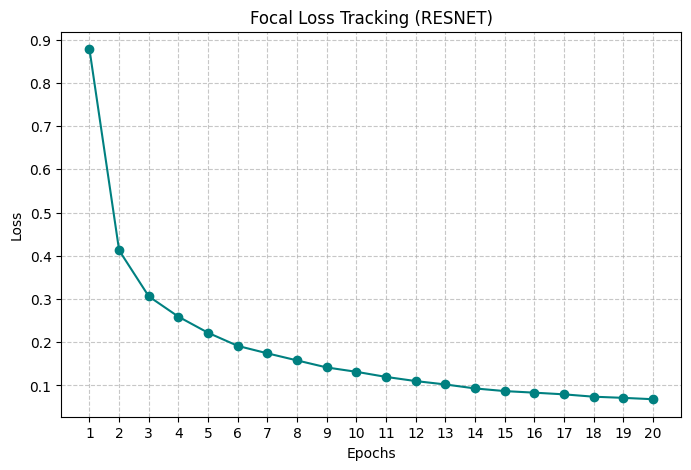

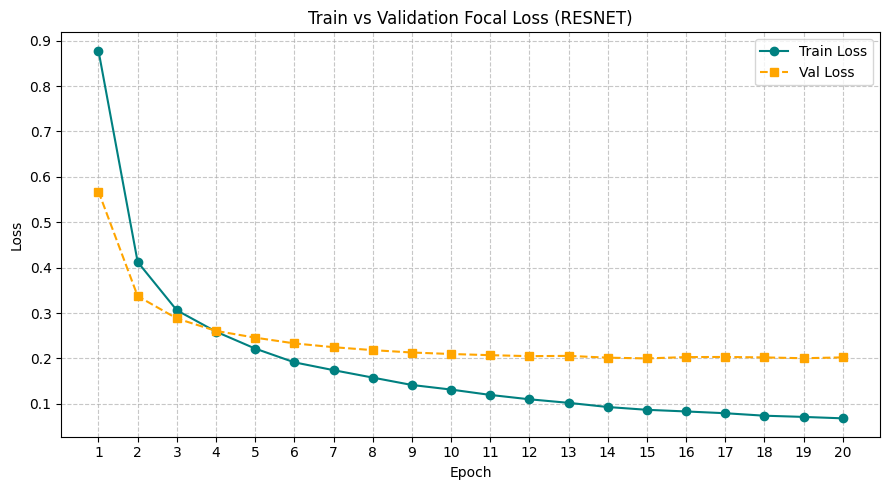

In [ ]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. THE FOCAL LOSS UPGRADE
# ---------------------------------------------------------
def focal_loss(logits, targets, alpha=0.25, gamma=2.0):
    """
    Calculates Focal Loss to destroy highly confident false positives (like the spine).
    """
    # 1. Calculate standard BCE (reduction='none' keeps the loss per-pixel)
    bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    
    # 2. Get the raw probabilities back to determine confidence
    pt = torch.exp(-bce_loss) 
    
    # 3. Apply the Focal math: alpha * (1 - pt)^gamma * BCE
    # If confidence is high but wrong, (1-pt) becomes massive.
    f_loss = alpha * (1 - pt)**gamma * bce_loss
    
    return f_loss.mean()

def custom_focal_grid_loss_fn(predictions, targets, lambda_coord=5.0):
    # --- 1. CLASSIFICATION (FOCAL LOSS) ---
    mask_true_pos = targets[..., 0] == 1.0
    mask_true_neg = targets[..., 0] == 0.0
    
    # Replace BCE with our new Focal Loss!
    loss_class_pos = focal_loss(predictions[mask_true_pos][..., 0], targets[mask_true_pos][..., 0], alpha=0.75)
    loss_class_neg = focal_loss(predictions[mask_true_neg][..., 0], targets[mask_true_neg][..., 0], alpha=0.25)
    
    # Notice we don't need lambda_noobj anymore; alpha and gamma handle the balancing naturally.
    total_class_loss = loss_class_pos + loss_class_neg
    
    # --- 2. LOCALIZATION (BOX REGRESSION) ---
    if mask_true_pos.sum() > 0:
        # Sigmoid forces the predictions to stay between 0 and 1 (local cell offsets)
        valid_pred_boxes = torch.sigmoid(predictions[mask_true_pos][:, 1:5]) 
        valid_target_boxes = targets[mask_true_pos][:, 1:5]
        loss_box = F.mse_loss(valid_pred_boxes, valid_target_boxes)
    else:
        loss_box = 0.0
        
    return total_class_loss + (lambda_coord * loss_box) 

# ---------------------------------------------------------
# 2. THE TRAINING LOOP
# ---------------------------------------------------------
def train_loop(dataloader, model, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        
        pred = model(X)
        # Call the new Focal Loss function
        loss = custom_focal_grid_loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

def val_loop(dataloader, model, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = custom_focal_grid_loss_fn(pred, y)
            total_loss += loss.item()
    return total_loss / len(dataloader)

# ---------------------------------------------------------
# 3. EXECUTION SETUP
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}\n")

# ==========================================
# THE ARCHITECTURE TOGGLE
# ==========================================
# Change this to "CUSTOM" or "RESNET"
ACTIVE_MODEL = "RESNET" 

if ACTIVE_MODEL == "CUSTOM":
    print("Mounting Custom Deep Grid Network...")
    model = DeepGridStoneNet().to(device)
    # Custom networks usually need a slightly higher learning rate to get started
    learning_rate = 1e-3 

elif ACTIVE_MODEL == "RESNET":
    print("Mounting Pre-trained ResNet-18 Backbone...")
    model = ResNetGridStoneDetector().to(device)
    # Pre-trained networks need a smaller learning rate so they don't overwrite their existing knowledge
    learning_rate = 1e-2
else:
    raise ValueError("Invalid model selected! Please choose 'CUSTOM' or 'RESNET'.")
# ==========================================

# Initialize the optimizer with the dynamically selected model
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

epochs = 8
train_losses = []
val_losses = []

for t in range(epochs):
    print(f"Epoch {t+1}/{epochs}\n-------------------------------")
    avg_train_loss = train_loop(train_dataloader, model, optimizer, device)
    avg_val_loss   = val_loop(valid_dataloader, model, device)
    scheduler.step(avg_val_loss)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)    
    print(f"Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}\n")

print(f"Training Complete for {ACTIVE_MODEL}!")

# Plot results
color = 'purple' if ACTIVE_MODEL == "CUSTOM" else 'teal'
plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', color=color,    label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses,   marker='s', color='orange', label='Val Loss', linestyle='--')
plt.title(f'Train vs Validation Focal Loss ({ACTIVE_MODEL})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Inference Mode

In [9]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. DEFINE THE DATASET CLASS
class GridStoneDetectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, grid_size=7, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.grid_size = grid_size
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(self.labels_dir, txt_name)
        
        target = torch.zeros((self.grid_size, self.grid_size, 5), dtype=torch.float32)
        
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
            with open(txt_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5 and parts[0] == '0':
                        x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                        
                        grid_x_float = x_c * self.grid_size
                        grid_y_float = y_c * self.grid_size
                        
                        grid_x = min(int(grid_x_float), self.grid_size - 1)
                        grid_y = min(int(grid_y_float), self.grid_size - 1)
                        
                        offset_x = grid_x_float - grid_x
                        offset_y = grid_y_float - grid_y
                        
                        if target[grid_y, grid_x, 0] == 0:
                            target[grid_y, grid_x, 0] = 1.0      
                            target[grid_y, grid_x, 1] = offset_x 
                            target[grid_y, grid_x, 2] = offset_y 
                            target[grid_y, grid_x, 3] = w_norm   
                            target[grid_y, grid_x, 4] = h_norm   
                        
        if self.transform: image = self.transform(image)
        return image, target

# 2. LOAD THE VALIDATION DATA
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

base_dir = 'C:/Users/julia/OneDrive - purdue.edu/2026 Spring/BME 450/Final'

# This creates the 'valid_data' variable your inference cell is looking for!
valid_data = GridStoneDetectionDataset(
    images_dir=f'{base_dir}/valid/images', 
    labels_dir=f'{base_dir}/valid/labels', 
    transform=data_transforms
)

print(f"Validation dataset loaded! Found {len(valid_data)} scans.")

Validation dataset loaded! Found 123 scans.


Starting batch validation on 5 random CT scans...

========== DIAGNOSTIC REPORT: SCAN 1 ==========
Ground Truth (Actual Calculi): 2
Model Detections: 4

Stone 1 [FALSE POSITIVE (Poor Localization)]: Conf=79.0% | W=10.4px, H=12.9px
Stone 2 [FALSE POSITIVE (Poor Localization)]: Conf=75.0% | W=12.4px, H=19.8px
Stone 3 [FALSE POSITIVE (Poor Localization)]: Conf=64.5% | W=29.8px, H=9.7px
Stone 4 [FALSE POSITIVE (Poor Localization)]: Conf=53.3% | W=29.7px, H=36.4px


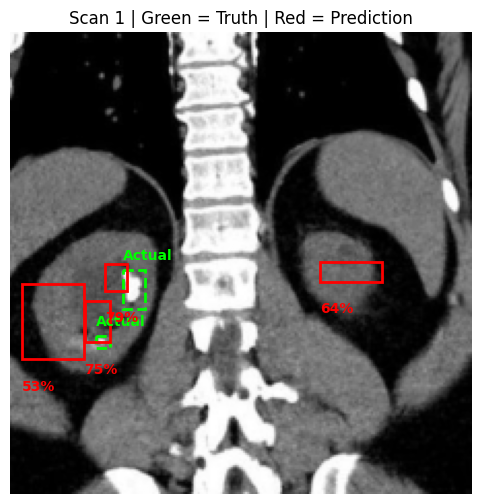



========== DIAGNOSTIC REPORT: SCAN 2 ==========
Ground Truth (Actual Calculi): 2
Model Detections: 5

Stone 1 [FALSE POSITIVE (Poor Localization)]: Conf=81.0% | W=14.5px, H=2.9px
Stone 2 [FALSE POSITIVE (Poor Localization)]: Conf=75.2% | W=18.8px, H=5.8px
Stone 3 [FALSE POSITIVE (Poor Localization)]: Conf=69.9% | W=6.3px, H=14.6px
Stone 4 [FALSE POSITIVE (Poor Localization)]: Conf=65.1% | W=7.0px, H=11.2px
Stone 5 [FALSE POSITIVE (Poor Localization)]: Conf=56.6% | W=10.4px, H=13.1px


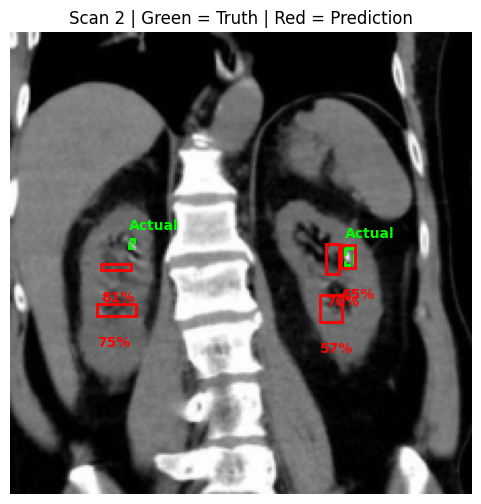



========== DIAGNOSTIC REPORT: SCAN 3 ==========
Ground Truth (Actual Calculi): 1
Model Detections: 7

Stone 1 [FALSE POSITIVE (Poor Localization)]: Conf=92.2% | W=2.0px, H=3.5px
Stone 2 [FALSE POSITIVE (Poor Localization)]: Conf=83.1% | W=4.7px, H=2.6px
Stone 3 [FALSE POSITIVE (Poor Localization)]: Conf=80.0% | W=4.4px, H=3.0px
Stone 4 [FALSE POSITIVE (Poor Localization)]: Conf=69.1% | W=6.8px, H=7.5px
Stone 5 [FALSE POSITIVE (Poor Localization)]: Conf=62.3% | W=10.4px, H=14.5px
Stone 6 [FALSE POSITIVE (Poor Localization)]: Conf=57.0% | W=11.2px, H=4.9px
Stone 7 [FALSE POSITIVE (Poor Localization)]: Conf=52.7% | W=51.5px, H=17.6px


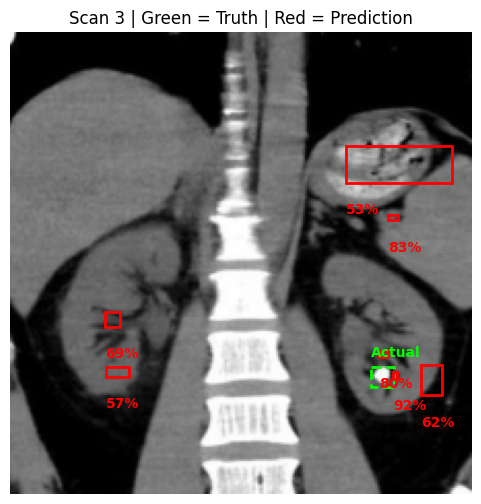



========== DIAGNOSTIC REPORT: SCAN 4 ==========
Ground Truth (Actual Calculi): 3
Model Detections: 10

Stone 1 [FALSE POSITIVE (Poor Localization)]: Conf=92.8% | W=2.7px, H=3.5px
Stone 2 [FALSE POSITIVE (Poor Localization)]: Conf=89.2% | W=2.1px, H=5.9px
Stone 3 [FALSE POSITIVE (Poor Localization)]: Conf=83.1% | W=3.1px, H=3.0px
Stone 4 [FALSE POSITIVE (Poor Localization)]: Conf=80.9% | W=1.2px, H=3.6px
Stone 5 [FALSE POSITIVE (Poor Localization)]: Conf=69.0% | W=6.7px, H=10.0px
Stone 6 [FALSE POSITIVE (Poor Localization)]: Conf=62.7% | W=3.6px, H=2.2px
Stone 7 [FALSE POSITIVE (Poor Localization)]: Conf=62.2% | W=12.4px, H=13.5px
Stone 8 [FALSE POSITIVE (Poor Localization)]: Conf=57.0% | W=6.1px, H=2.6px
Stone 9 [FALSE POSITIVE (Poor Localization)]: Conf=53.1% | W=3.8px, H=6.0px
Stone 10 [FALSE POSITIVE (Poor Localization)]: Conf=51.7% | W=12.5px, H=15.6px


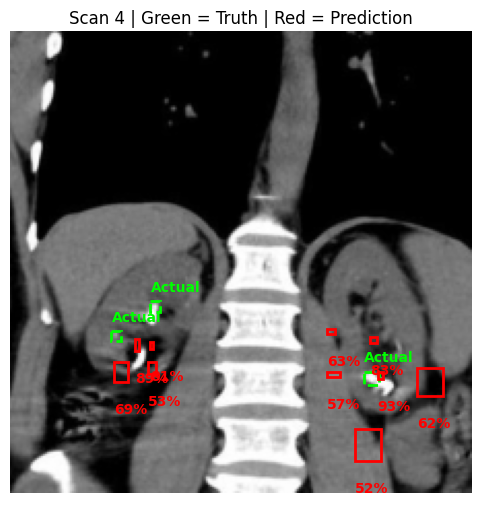



========== DIAGNOSTIC REPORT: SCAN 5 ==========
Ground Truth (Actual Calculi): 2
Model Detections: 3

Stone 1 [FALSE POSITIVE (Poor Localization)]: Conf=68.2% | W=4.0px, H=5.5px
Stone 2 [FALSE POSITIVE (Poor Localization)]: Conf=62.2% | W=6.7px, H=5.3px
Stone 3 [FALSE POSITIVE (Poor Localization)]: Conf=51.7% | W=5.4px, H=3.4px


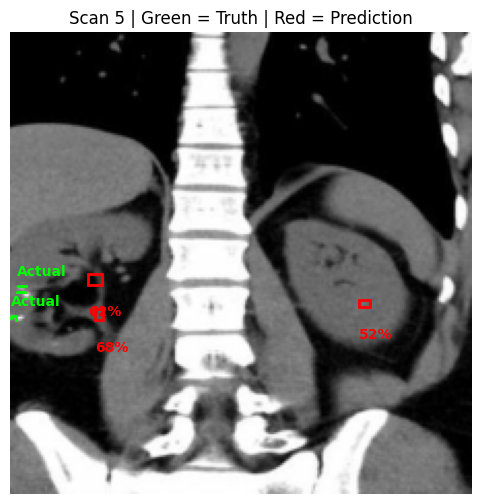

In [10]:
import torch
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import box_iou, nms

# ---------------------------------------------------------
# SETUP BATCH VALIDATION
# ---------------------------------------------------------
model.eval()
num_samples_to_test = 5 
IMG_SIZE = 224 # Resized dimension from our transforms

total_valid_scans = len(valid_data)
sample_indices = random.sample(range(total_valid_scans), min(num_samples_to_test, total_valid_scans))

print(f"Starting batch validation on {len(sample_indices)} random CT scans...\n")

for batch_num, sample_index in enumerate(sample_indices):
    print(f"========== DIAGNOSTIC REPORT: SCAN {batch_num + 1} ==========")
    
    # ---------------------------------------------------------
    # 1. INFERENCE & GRID PARSING
    # ---------------------------------------------------------
    image_tensor, true_target = valid_data[sample_index]

    with torch.no_grad():
        input_tensor = image_tensor.unsqueeze(0).to(device)
        prediction = model(input_tensor)[0].cpu()

    # Apply Sigmoid to bound the network's logits between 0 and 1
    pred_probs = torch.sigmoid(prediction[..., 0])
    pred_boxes = torch.sigmoid(prediction[..., 1:5]) 
    
    detected_mask = pred_probs > 0.5
    detected_cells = detected_mask.nonzero(as_tuple=False)
    
    raw_pred_boxes = []
    raw_pred_scores = []
    
    # Extract predictions and reverse the cell-offset math
    for cell in detected_cells:
        y_idx, x_idx = cell[0], cell[1]
        score = pred_probs[y_idx, x_idx].item()
        offset_x, offset_y, w_norm, h_norm = pred_boxes[y_idx, x_idx]
        
        global_x_c = (x_idx + offset_x) / 7.0
        global_y_c = (y_idx + offset_y) / 7.0
        
        w = w_norm * IMG_SIZE
        h = h_norm * IMG_SIZE
        x_min = (global_x_c * IMG_SIZE) - (w / 2)
        y_min = (global_y_c * IMG_SIZE) - (h / 2)
        
        raw_pred_boxes.append([x_min, y_min, x_min + w, y_min + h])
        raw_pred_scores.append(score)

    # ---------------------------------------------------------
    # 2. NON-MAXIMUM SUPPRESSION (FILTERING)
    # ---------------------------------------------------------
    if len(raw_pred_boxes) > 0:
        boxes_tensor = torch.tensor(raw_pred_boxes, dtype=torch.float32)
        scores_tensor = torch.tensor(raw_pred_scores, dtype=torch.float32)
        
        # Remove overlapping duplicate boxes predicted by neighboring cells
        nms_threshold = 0.1
        keep_indices = nms(boxes_tensor, scores_tensor, nms_threshold)
        
        valid_boxes = boxes_tensor[keep_indices]
        valid_scores = scores_tensor[keep_indices]
    else:
        valid_boxes = torch.empty((0, 4))
        valid_scores = torch.empty((0,))

    # ---------------------------------------------------------
    # 3. GROUND TRUTH PARSING
    # ---------------------------------------------------------
    true_probs = true_target[..., 0]
    true_boxes_raw = true_target[..., 1:5]
    true_cells = (true_probs == 1.0).nonzero(as_tuple=False)
    
    parsed_true_boxes = []
    for cell in true_cells:
        y_idx, x_idx = cell[0], cell[1]
        offset_x, offset_y, w_norm, h_norm = true_boxes_raw[y_idx, x_idx]
        
        global_x_c = (x_idx + offset_x) / 7.0
        global_y_c = (y_idx + offset_y) / 7.0
        
        w = w_norm * IMG_SIZE
        h = h_norm * IMG_SIZE
        x_min = (global_x_c * IMG_SIZE) - (w / 2)
        y_min = (global_y_c * IMG_SIZE) - (h / 2)
        
        parsed_true_boxes.append([x_min, y_min, x_min + w, y_min + h])
        
    true_boxes = torch.tensor(parsed_true_boxes, dtype=torch.float32) if len(parsed_true_boxes) > 0 else torch.empty((0, 4))

    # ---------------------------------------------------------
    # 4. ACCURACY EVALUATION
    # ---------------------------------------------------------
    num_true = len(true_boxes)
    num_pred = len(valid_boxes)

    print(f"Ground Truth (Actual Calculi): {num_true}")
    print(f"Model Detections: {num_pred}\n")

    if num_true > 0 and num_pred > 0:
        ious = box_iou(valid_boxes, true_boxes)
        for i, box in enumerate(valid_boxes):
            x_min, y_min, x_max, y_max = box
            width, height = x_max - x_min, y_max - y_min
            conf = valid_scores[i].item() * 100
            
            best_iou = ious[i].max().item()
            status = "CORRECT" if best_iou > 0.5 else "FALSE POSITIVE (Poor Localization)"
            
            print(f"Stone {i+1} [{status}]: Conf={conf:.1f}% | W={width.item():.1f}px, H={height.item():.1f}px")
            
    elif num_pred > 0 and num_true == 0:
        print("Result: False Positives detected on a healthy scan.")
    elif num_pred == 0 and num_true > 0:
        print("Result: False Negatives. Model missed the calculi.")
    else:
        print("Result: Correctly identified healthy scan (True Negative).")

    # ---------------------------------------------------------
    # 5. VISUALIZATION
    # ---------------------------------------------------------
    image_to_plot = image_tensor.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(image_to_plot)

    # Draw GROUND TRUTH (Green Dashed)
    for box in true_boxes:
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min.item(), y_min.item()), 
                                 x_max.item() - x_min.item(), y_max.item() - y_min.item(), 
                                 linewidth=2, edgecolor='lime', linestyle='--', facecolor='none')
        ax.add_patch(rect)
        plt.text(x_min.item(), y_min.item() - 5, 'Actual', color='lime', weight='bold')

    # Draw PREDICTIONS (Red Solid)
    for i, box in enumerate(valid_boxes):
        x_min, y_min, x_max, y_max = box
        conf = valid_scores[i].item() * 100
        rect = patches.Rectangle((x_min.item(), y_min.item()), 
                                 x_max.item() - x_min.item(), y_max.item() - y_min.item(), 
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        plt.text(x_min.item(), y_max.item() + 15, f'{conf:.0f}%', color='red', weight='bold')

    plt.axis('off')
    plt.title(f"Scan {batch_num + 1} | Green = Truth | Red = Prediction")
    plt.show()
    print("\n" + "="*50 + "\n")

# Demonstration of Dataset Format

Scanning 10 random files...



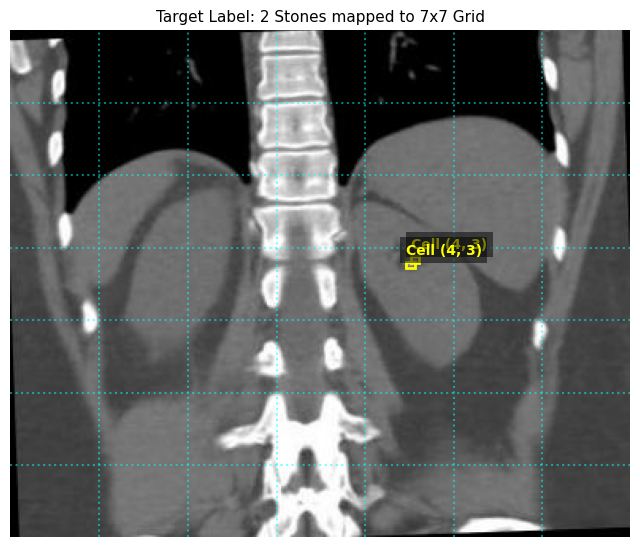

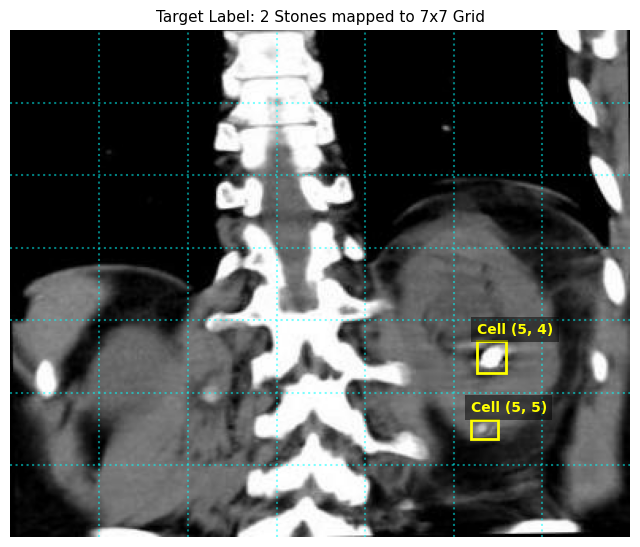

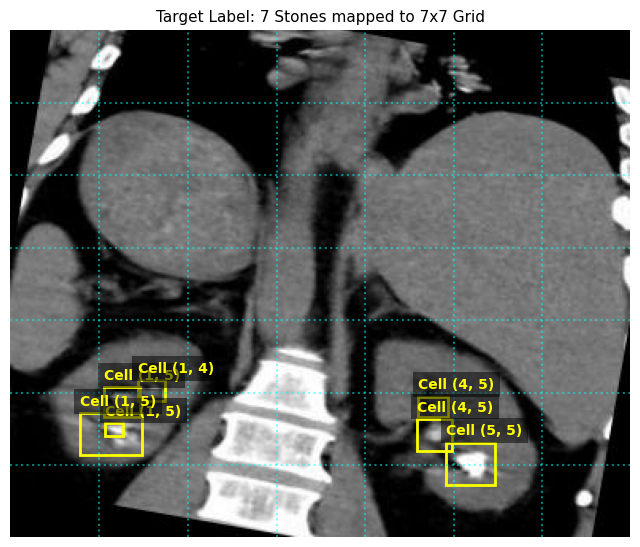

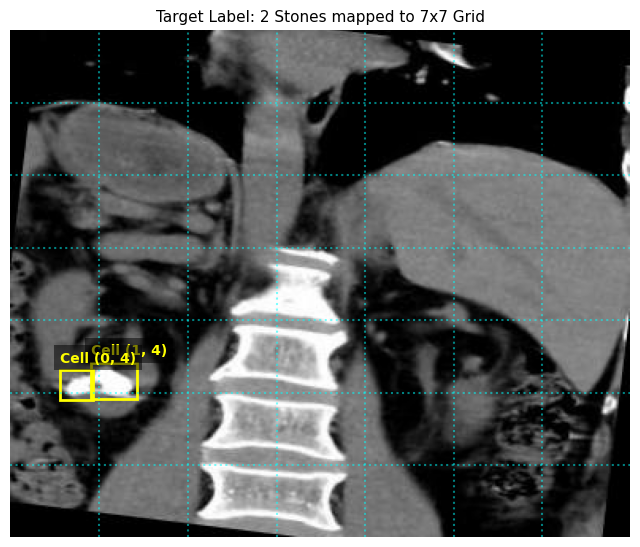

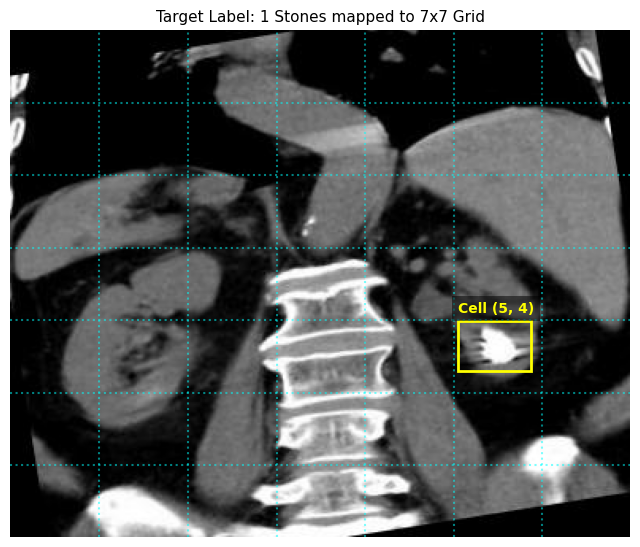

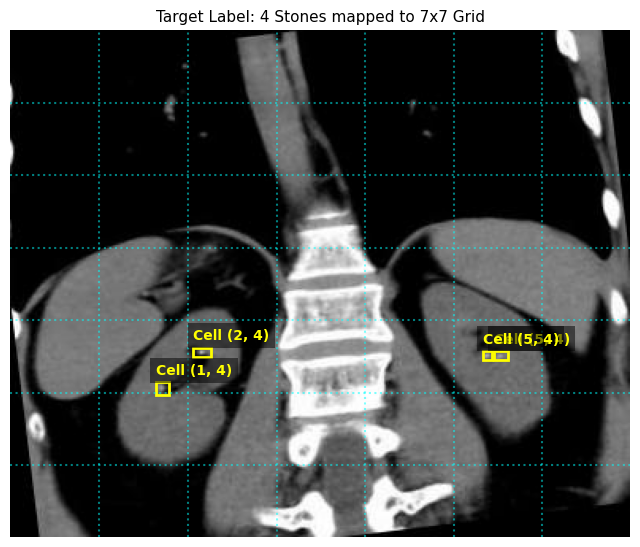

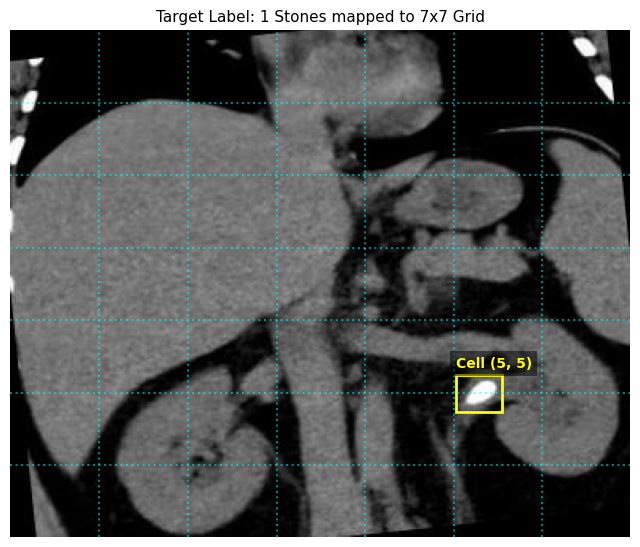

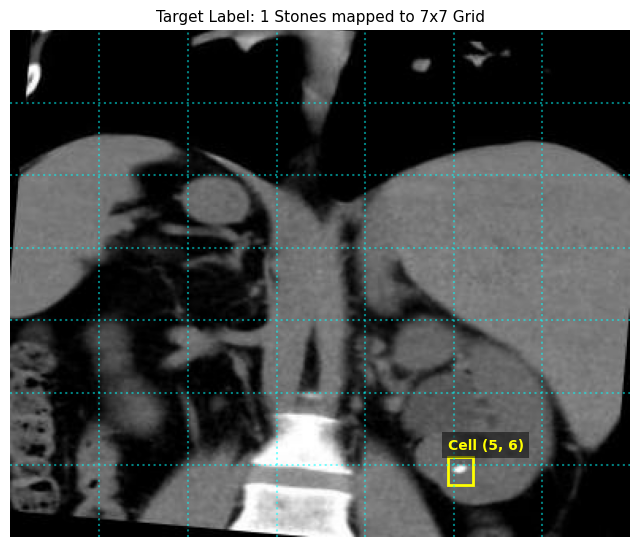

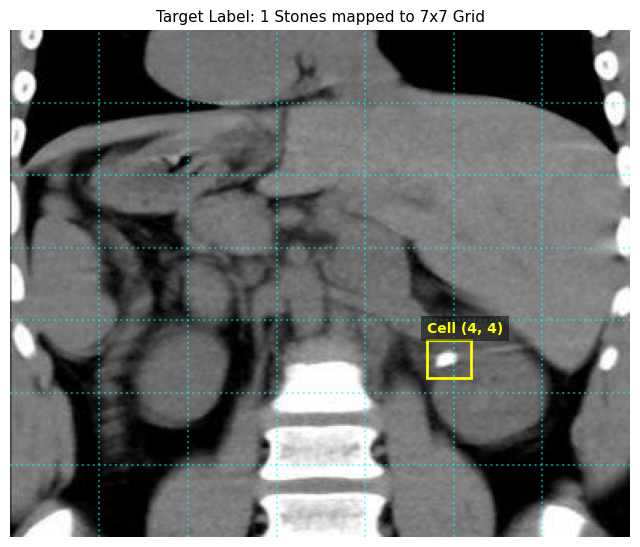

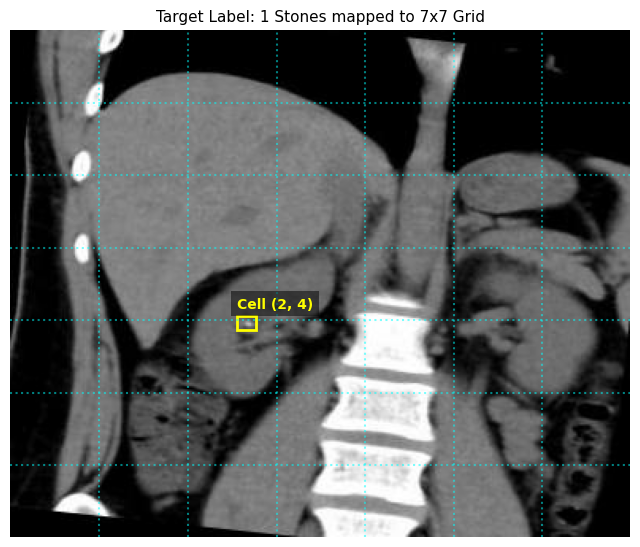

In [7]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def automated_grid_dataset_check(images_dir, labels_dir, num_samples=3, grid_size=7):
    """
    Randomly selects and visualizes images, overlays a 7x7 grid, 
    and shows which specific grid cell is responsible for each stone.
    """
    # 1. Grab every image file in the folder
    all_images = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    if not all_images:
        print(f"No images found in {images_dir}")
        return

    # 2. Pick a random subset to check
    random_samples = random.sample(all_images, min(num_samples, len(all_images)))
    print(f"Scanning {len(random_samples)} random files...\n")
    
    # 3. Loop through the randomly selected images
    for img_name in random_samples:
        img_path = os.path.join(images_dir, img_name)
        
        # Construct the matching label path automatically
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(labels_dir, txt_name)
        
        # Load the image
        img = Image.open(img_path).convert('RGB')
        img_width, img_height = img.size
        
        # Setup plotting
        fig, ax = plt.subplots(1, figsize=(8, 8))
        ax.imshow(img)
        
        # Draw the 7x7 Grid overlay for visual reference
        cell_w = img_width / grid_size
        cell_h = img_height / grid_size
        for i in range(1, grid_size):
            # Vertical lines
            ax.axvline(x=i * cell_w, color='cyan', linestyle=':', alpha=0.5)
            # Horizontal lines
            ax.axhline(y=i * cell_h, color='cyan', linestyle=':', alpha=0.5)
        
        stones_found = 0
        
        # Read the label file if it exists and isn't empty
        if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:
            with open(txt_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) >= 5 and parts[0] == '0':
                        stones_found += 1
                        x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                        
                        # Calculate absolute pixel coordinates
                        w = w_norm * img_width
                        h = h_norm * img_height
                        x_min = (x_c * img_width) - (w / 2)
                        y_min = (y_c * img_height) - (h / 2)
                        
                        # Calculate the Grid Cell index (0-6)
                        grid_x = min(int(x_c * grid_size), grid_size - 1)
                        grid_y = min(int(y_c * grid_size), grid_size - 1)
                        
                        # Draw the bounding box
                        rect = patches.Rectangle((x_min, y_min), w, h, 
                                                 linewidth=2, edgecolor='yellow', facecolor='none')
                        ax.add_patch(rect)
                        
                        # Label the stone with its assigned Grid Cell
                        plt.text(x_min, y_min - 5, f'Cell ({grid_x}, {grid_y})', 
                                 color='yellow', fontsize=10, weight='bold', 
                                 bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
                        
                        # Removed the 'break' statement so it loads ALL stones

        plt.axis('off')
        
        # Give each plot a clean title
        if stones_found > 0:
            plt.title(f"Target Label: {stones_found} Stones mapped to {grid_size}x{grid_size} Grid", fontsize=11)
        else:
            plt.title(f"Target Label: Healthy Scan (Empty Grid)", fontsize=11)
            
        plt.show()

# --- Automated Usage ---
base_dir = 'C:/Users/julia/OneDrive - purdue.edu/2026 Spring/BME 450/Final'

automated_grid_dataset_check(
    images_dir=f'{base_dir}/train/images', 
    labels_dir=f'{base_dir}/train/labels', 
    num_samples=10
)